##### ***注意力机制***
###### 在生物学中，美国心理学之父James提出了当今十分普及的双组件框架，在这个框架中受试者基于非自主性提示和自主性提示有选择的引导注意力的焦点。非自主性提示是基于环境中物体的突出性和易见性，而自主性提示是基于受试者自己的意图和目标。这个框架解释了人类的注意力方式，受它启发，如今也利用这两种注意力提示，用神经网络来设计注意力机制的框架。
##### ***查询、键、值***
###### 首先考虑一个相对简单的情况：也就是只用非自主性提示。要想将选择偏向感官输入，我们可以简单的使用参数化的全连接层，甚至是非参数化的最大汇聚层或者平均汇聚层。而它们都是基于感官输入的，而不是基于受试者自己的意图和目标。也就是说都是数据驱动的，如最大汇聚层看数据的大小，而不是任务驱动型的。
###### 因此“是都包含自主性提示”将注意力机制与全连接层或汇聚层区别开来。在注意力机制的背景下，自主性提示被称为查询(query)，。给定任何查询，注意力机制通过注意力汇聚(attention pooling)将选择引导至感官输入(sensory iputs，例如中间特征表示)。在注意力机制中，这些感官输入被称为值(value)，且每个值都与一个键(key)配对，这些可以想象为感官输入的非自主性提示，也就是说通过设计注意力汇聚的方式，使给定的查询（自主性提示）与键（非自主性提示）进行匹配，这将引导得出最匹配的值（感官输入）。
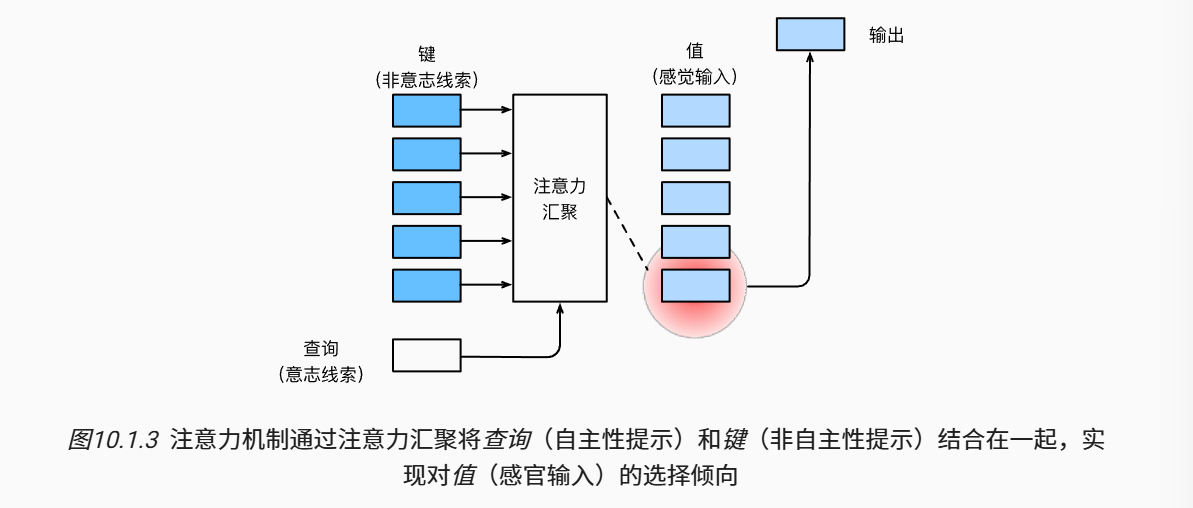

In [1]:
# 注意力的可视化
# 平均池化层可视为输入的加权平均，且各输入的权重是一样的。实际上注意力汇聚层也是加权平均，只是权重是根据查询和键进行计算的。
import torch
from d2l import torch as d2l

In [2]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5), cmap='Reds'):
    """可视化注意力矩阵"""
    d2l.use_svg_display()
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = d2l.plt.subplots(num_rows, num_cols, figsize=figsize, sharex=True, sharey=True, squeeze=False)

    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);


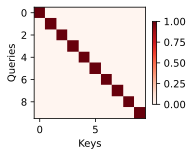

In [3]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')